# Residential rooftop PV with battery storage — Germany, end of 2023

Redraw of the left pie of the source figure below: of all residential rooftop PV systems
(building systems up to 30 kWp), **40 % (≈ 1.2 million) are combined with a battery
storage system**, 58 % are not, 2 % unknown.

Source: Fraunhofer ISE, based on Marktstammdatenregister (MaStR), 01.04.2024.
The figure is written to `<date>_<time>_out_<i>.pdf` next to this notebook.

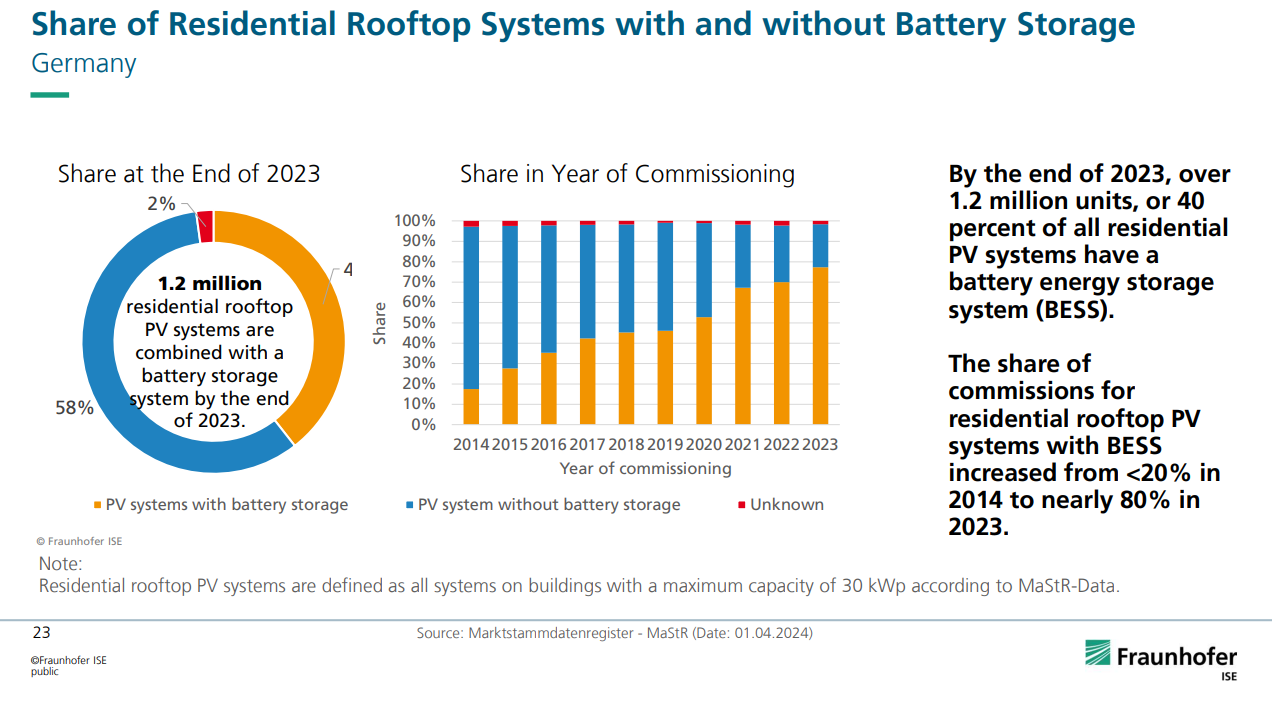

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

In [ ]:
from datetime import datetime
from pathlib import Path

# VS Code exposes the notebook path; a plain Jupyter kernel starts in the notebook's directory.
OUT_DIR = Path(globals()["__vsc_ipynb_file__"]).parent if "__vsc_ipynb_file__" in globals() else Path.cwd()
OUT_RUN_STAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
out_index = 0  # incremented once per saved artefact; reset by re-running this cell


def next_out_path(file_format: str) -> Path:
    """Next '<date>_<time>_out_<i>.<file_format>' path in this notebook's directory."""
    global out_index
    out_index += 1
    return OUT_DIR / f"{OUT_RUN_STAMP}_out_{out_index}.{file_format}"


In [41]:
# Data: share at the end of 2023
labels = [
    "PV systems with battery storage",
    "PV systems without battery storage",
    "Unknown",
]
shares = [40, 58, 2]

# Colours matching the source figure (orange / blue / red)
colors = ["#F5A623", "#2E86C1", "#E1121C"]

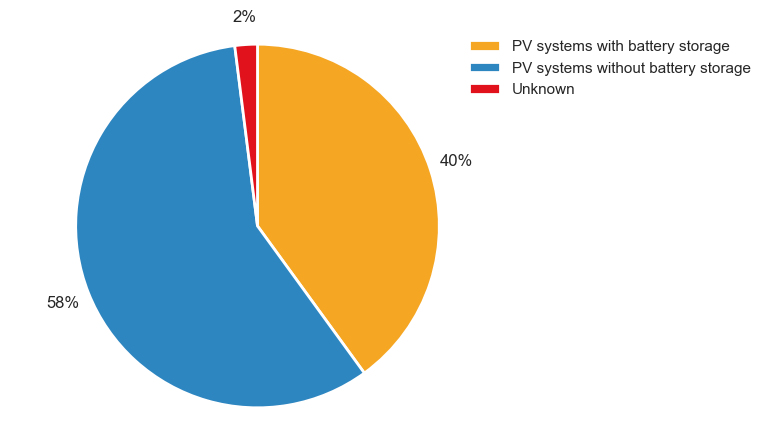

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))

wedges, _, autotexts = ax.pie(
    shares,
    colors=colors,
    radius=1.0,
    startangle=90,
    counterclock=False,
    autopct="%1.0f%%",
    pctdistance=1.15,  # push percentage labels outside the pie
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)

# Style the percentage labels sitting just outside each wedge
# for t in autotexts:
#     t.set_fontweight("bold")

ax.axis("equal")  # keep the pie circular

# Shift the pie to the left so the legend has its own space on the right
ax.set_position([0.02, 0.1, 0.55, 0.8])

# Legend to the right of the pie (title intentionally omitted)
ax.legend(
    wedges,
    labels,
    loc="upper left",
    bbox_to_anchor=(0.9, 1.0),
    frameon=False,
    ncol=1,
)

out_path = next_out_path("pdf")
fig.savefig(out_path, bbox_inches="tight")
print(f"saved {out_path}")
plt.show()